In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

# 1.1 Check array compatibility for taking a dot product [1 pt]
# Write a function dot_product_compatibility() that takes two arguments:
        # an array with shape (n, m) of n vectors, each with m elements
        # a target vector , also with m elements

# The function should return a Boolean indicating if the arguments are shaped correctly to allow us to compute the dot product of with each of the n vectors in X. 


def dot_product_compatibility(matrix, vector):
    """
    Checks if a matrix of shape (n, m) is compatible for 
    a dot product with a vector of m elements.
    """
    # 1. Ensure inputs are numpy arrays
    matrix = np.asarray(matrix)
    vector = np.asarray(vector)
    
    # 2. Check shapes
    # matrix.shape[1] is the number of columns (m)
    # vector.shape[0] is the number of elements in the vector
    if matrix.ndim == 2 and vector.ndim == 1:
        return matrix.shape[1] == vector.shape[0]
    
    return False


# Case 1: Compatible (n=2, m=3)
M1 = np.ones((2, 3))
V1 = np.ones(3)
print(dot_product_compatibility(M1, V1)) # Expected: True

# Case 2: Incompatible (m=3 vs vector=2)
V2 = np.ones(2)
print(dot_product_compatibility(M1, V2)) # Expected: False


True
False


In [4]:
# Write a function maximize_dot_product() that takes two arguments: 
    # an array  with shape (n, m) of n vectors, each with m elements
    # a target vector , also with m elements

# This function should do the following: 
    # Check if the arguments are compatible using dot_product_compatibility. If not, the function should print, "Arrays are not compatible shapes" and the function should return None.
    # If the arguments are compatible, return the index of the vector in  that maximizes the dot product with target vector .

def maximize_dot_product(matrix, target_vector):
    # 1. Convert to numpy arrays to ensure shape attributes exist
    matrix = np.asarray(matrix)
    target_vector = np.asarray(target_vector)
    
    # 2. Check compatibility
    if not dot_product_compatibility(matrix, target_vector):
        print("Arrays are not compatible shapes")
        return None
    
    # 3. Compute dot products for all n vectors at once
    # Result is an array of length n
    dot_products = matrix @ target_vector
    
    # 4. Find the index of the maximum value
    best_index = np.argmax(dot_products)
    
    return best_index


# Example Data
vectors = np.array([
    [1, 0, 0], # Index 0
    [0, 1, 0], # Index 1
    [1, 1, 1]  # Index 2
])
target = np.array([0.1, 0.8, 0.1])

# This should return Index 1 because [0, 1, 0] is the closest match
print(maximize_dot_product(vectors, target))

2


In [16]:
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
B = np.array([1, 2, 3])

elementwise_AB = A * B
elementwise_BA = B * A
print(f"is_elementwise_commutative = {np.array_equal(elementwise_AB , elementwise_BA)}")

dotproduct_AB = np.dot(A,B)
dotproduct_BA = np.dot(B,A)
print(f"is_dotproduct_commutative = {np.array_equal(dotproduct_AB , dotproduct_BA)}")

matmul_AB = A @ B
matmul_BA = B @ A
print(f"is_matmul_commutative = {np.array_equal(matmul_AB , matmul_BA)}")




is_elementwise_commutative = True
is_dotproduct_commutative = False
is_matmul_commutative = False


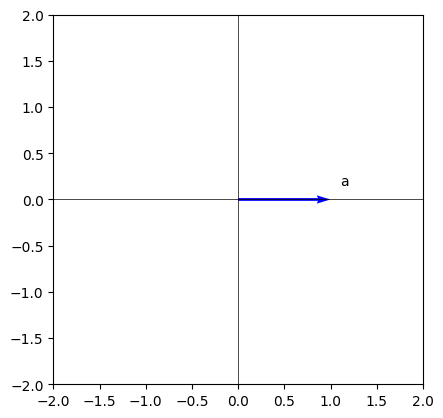

In [17]:
def make_axes():
    plt.axvline(0, color='black', lw=0.5)
    plt.axhline(0, color='black', lw=0.5)
    # Scale the plot 
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.gca().set_aspect('equal', adjustable='box')
    fig = plt.gca()
    return fig

def add_vector_to_figure(figure, v, color='black', label=None):
    origin = np.array([0,0])
    figure.quiver(*origin, *v, scale=1, scale_units='xy', angles='xy', color=color)
    if label is not None:
        figure.annotate(label, v, textcoords="offset points", xytext=(10,10), ha='center')

a = np.array([1, 0])

fig = make_axes()
add_vector_to_figure(fig, a, color='blue', label='a')

In [23]:


def get_rotation_matrix(angle_degrees):
    """
    Returns a 2x2 numpy array representing the rotation matrix 
    for a given angle in degrees.
    """
    # Convert degrees to radians
    theta = np.radians(angle_degrees)
    
    # Calculate cos and sin
    c, s = np.cos(theta), np.sin(theta)
    
    # Create the 2x2 matrix
    rotation_matrix = np.array([
        [c, -s],
        [s,  c]
    ])
    
    return rotation_matrix



In [25]:
def rotate_vector(v, angle_degrees):
    """
    Rotates a vector v by a given angle in degrees using a rotation matrix.
    """
    # 1. Get the 2x2 rotation matrix
    R = get_rotation_matrix(angle_degrees)
    
    # 2. Perform matrix multiplication (R @ v)
    # The @ operator is the standard way to compute the dot product for transformation
    v_transformed = R @ v
    
    return v_transformed

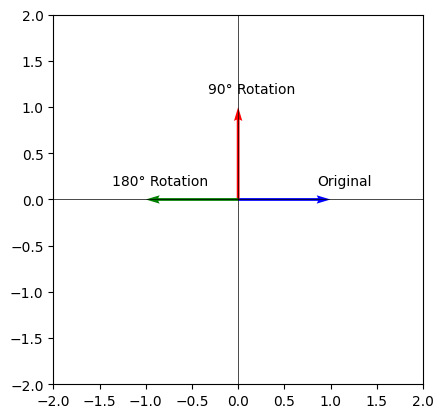

In [26]:
# Define your original vector
a = np.array([1, 0])

# Rotate it 90 degrees (should point straight up to [0, 1])
a_90 = rotate_vector(a, 90)

# Rotate it 180 degrees (should point to [-1, 0])
a_180 = rotate_vector(a, 180)

# Visualize using your plotting functions
fig = make_axes()
add_vector_to_figure(fig, a, color='blue', label='Original')
add_vector_to_figure(fig, a_90, color='red', label='90° Rotation')
add_vector_to_figure(fig, a_180, color='green', label='180° Rotation')

plt.show()

In [ ]:
rot90 = get_rotation_matrix(90)
rot180 = get_rotation_matrix(180)

rot90twice = rot90 @ rot90
np.array_equal(rot180, rot90twice)



False

In [31]:
rot270 = rot90 @ rot180
np.array_equal(rot270, get_rotation_matrix(270))

True